In [1]:
import sleap
import sys
import json
import os
import pandas as pd
import joblib
from matplotlib import animation

sys.path.append('..')
sys.path.append('/Users/mingxiaowei/Desktop/kennedylab/turbulence/jelly-sleap/sleap/jelly/python')
from python.polygon_based_correction import *
# from python.animation import *
from eval.eval import *
from python.dataset_conversion import *
# from python.misprediction_classifier import *
from autoencoder.src.data_loader import *
from interpolate import *

sleap.versions()
sleap.system_summary()

HOME_DIR = '/Users/mingxiaowei/Desktop/kennedylab/turbulence/'

SLEAP: 1.4.1
TensorFlow: 2.9.2
Numpy: 1.24.4
Python: 3.9.21
OS: macOS-15.3.2-arm64-arm-64bit
GPUs: 1/1 available
  Device: /physical_device:GPU:0
         Available: True
       Initialized: False
     Memory growth: None


In [2]:
corrected_dataset_path = os.path.join(HOME_DIR, 'jellyfish/video/video_1_clips/correction_test/a1_1h_20s_corrected_with_scores_simplemax.slp')
corrected_dataset = sleap.load_file(corrected_dataset_path)
print(corrected_dataset)
gt_pts = get_all_tracked_points(corrected_dataset, interpolate=False, use_labeled_only=False, reorder=False, start_idx=0)

Labels(labeled_frames=3000, videos=1, skeletons=1, tracks=17)
all_tracked_points shape: (3000, 17, 2)
First non missing frame idx: 0
Missing point count: 0


# distribution

(2999, 17)


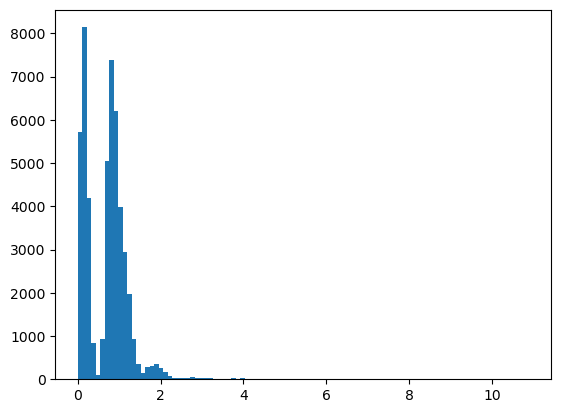

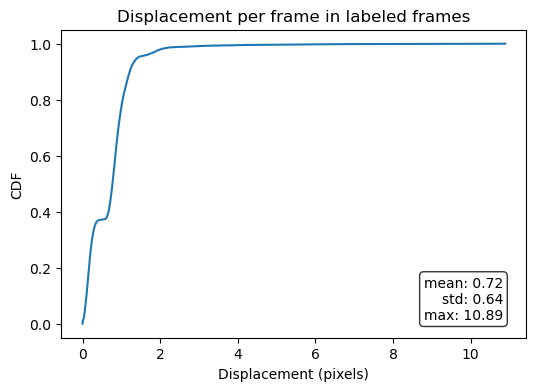

mean: 0.7150826156669623, std: 0.6359014701194633, max: 10.88835888519954


In [3]:
displacement = gt_pts[:-1] - gt_pts[1:]
displacement_norm = np.linalg.norm(displacement, axis=2)
print(displacement_norm.shape)
plt.hist(displacement_norm.flatten(), bins=100)
# plt.xscale('log')
plt.show()
# plot cdf

plt.figure(figsize=(6, 4))
plt.plot(np.sort(displacement_norm.flatten()), np.arange(len(displacement_norm.flatten())) / len(displacement_norm.flatten()))
plt.xlabel('Displacement (pixels)')
plt.ylabel('CDF')
plt.title('Displacement per frame in labeled frames')
# Calculate statistics
mean = np.mean(displacement_norm)
std = np.std(displacement_norm)
max_val = np.max(displacement_norm)

# Add text box with statistics
stats_text = f'mean: {mean:.2f}\nstd: {std:.2f}\nmax: {max_val:.2f}'
plt.text(0.95, 0.05, stats_text,
         transform=plt.gca().transAxes,
         verticalalignment='bottom',
         horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.show()
print(f'mean: {np.mean(displacement_norm)}, std: {np.std(displacement_norm)}, max: {np.max(displacement_norm)}')

# neighbor conditioned

In [4]:
prev_flow = np.roll(displacement_norm, -1, axis=1)
next_flow = np.roll(displacement_norm, 1, axis=1)
nn_flow = np.stack([prev_flow, next_flow], axis=2)

avg_flow = nn_flow.mean(axis=2)
avg_flow_flat = avg_flow.flatten()
max_flow = nn_flow.max(axis=2)
max_flow_flat = max_flow.flatten()
min_flow = nn_flow.min(axis=2)
min_flow_flat = min_flow.flatten()
pt_flow_flat = displacement_norm.flatten()

## correlation

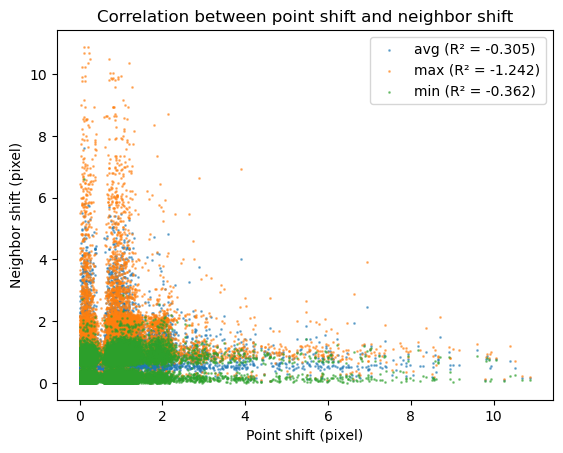

In [5]:
# Calculate R² values
from sklearn.metrics import r2_score

r2_avg = r2_score(pt_flow_flat, avg_flow_flat)
r2_max = r2_score(pt_flow_flat, max_flow_flat)
r2_min = r2_score(pt_flow_flat, min_flow_flat)

# Create scatter plots with R² values in legend
alpha = 0.5
s = 1
plt.scatter(pt_flow_flat, avg_flow_flat, alpha=alpha, s=s, label=f'avg (R² = {r2_avg:.3f})')
plt.scatter(pt_flow_flat, max_flow_flat, alpha=alpha, s=s, label=f'max (R² = {r2_max:.3f})')
plt.scatter(pt_flow_flat, min_flow_flat, alpha=alpha, s=s, label=f'min (R² = {r2_min:.3f})')
plt.xlabel('Point shift (pixel)')
plt.ylabel('Neighbor shift (pixel)')
plt.title('Correlation between point shift and neighbor shift')
plt.legend()
plt.show()

## pixel error

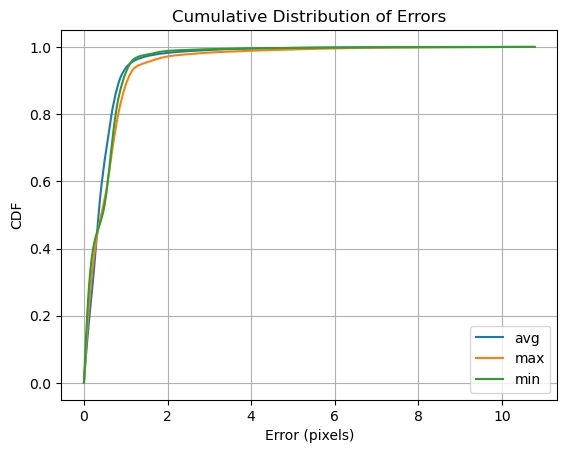

In [6]:
avg_err = np.abs(avg_flow_flat - pt_flow_flat)
max_err = np.abs(max_flow_flat - pt_flow_flat)
min_err = np.abs(min_flow_flat - pt_flow_flat)
plt.plot(np.sort(avg_err), np.arange(len(avg_err)) / len(avg_err), label='avg')
plt.plot(np.sort(max_err), np.arange(len(max_err)) / len(max_err), label='max') 
plt.plot(np.sort(min_err), np.arange(len(min_err)) / len(min_err), label='min')
plt.xlabel('Error (pixels)')
plt.ylabel('CDF')
plt.title('Cumulative Distribution of Errors')
plt.legend()
plt.grid(True)
plt.show()

# regression

## generate dataset

In [24]:
arr = np.array([0, 1, 2, 3, 4, 5, 6])
# arr = np.array([0, 1, 2, 3, 4, 5])
for i in range(len(arr)):
    nns = np.zeros(len(arr) - 1)
    arr_copy = np.delete(arr, i)
    arr_copy = np.roll(arr_copy, -i)
    print(f'remove {i}:')
    prev_idx = 0
    next_idx = len(nns) - 1
    j = 0
    while prev_idx < next_idx:
        nns[j] = arr_copy[prev_idx]
        j += 1
        nns[j] = arr_copy[next_idx]
        j += 1
        prev_idx += 1
        next_idx -= 1
    if prev_idx == next_idx:
        nns[j] = arr_copy[prev_idx]
    print(nns)
    

remove 0:
[1. 6. 2. 5. 3. 4.]
remove 1:
[2. 0. 3. 6. 4. 5.]
remove 2:
[3. 1. 4. 0. 5. 6.]
remove 3:
[4. 2. 5. 1. 6. 0.]
remove 4:
[5. 3. 6. 2. 0. 1.]
remove 5:
[6. 4. 0. 3. 1. 2.]
remove 6:
[0. 5. 1. 4. 2. 3.]


In [21]:
arr = np.array([0, 1, 2, 3, 4, 5, 6])
for i in range(len(arr)):
    arr_copy = np.delete(arr, i)
    print(f'remove {i}:')
    print(arr_copy)
    print(np.roll(arr_copy, - i))
# print(np.roll(arr, -1))
# print(np.roll(arr, 1))
# print(np.roll(arr, 5))
# 0 -> 1
# 1 -> 0
# 2 -> -1

remove 0:
[1 2 3 4 5 6]
[1 2 3 4 5 6]
remove 1:
[0 2 3 4 5 6]
[2 3 4 5 6 0]
remove 2:
[0 1 3 4 5 6]
[3 4 5 6 0 1]
remove 3:
[0 1 2 4 5 6]
[4 5 6 0 1 2]
remove 4:
[0 1 2 3 5 6]
[5 6 0 1 2 3]
remove 5:
[0 1 2 3 4 6]
[6 0 1 2 3 4]
remove 6:
[0 1 2 3 4 5]
[0 1 2 3 4 5]


In [7]:
frame_cnt, pt_cnt = displacement_norm.shape[:2]
y_data = displacement_norm.flatten()
X_data = np.zeros((frame_cnt, pt_cnt, pt_cnt - 1), dtype=np.float32)

for frame_idx in range(frame_cnt):
    for pt_idx in range(pt_cnt):
        pt_nns = np.delete(displacement_norm[frame_idx], pt_idx)
        pts_nns = np.roll(pt_nns, - pt_idx)
        prev_idx = 0
        next_idx = len(pts_nns) - 1
        j = 0
        while prev_idx < next_idx:
            X_data[frame_idx, pt_idx, j] = pts_nns[prev_idx]
            X_data[frame_idx, pt_idx, j + 1] = pts_nns[next_idx]
            j += 2
            prev_idx += 1
            next_idx -= 1
        if prev_idx == next_idx:
            X_data[frame_idx, pt_idx, j] = pts_nns[prev_idx]
X_data = X_data.reshape(-1, pt_cnt - 1)

print(X_data.shape)
print(y_data.shape)


(50983, 16)
(50983,)


## eval functions

In [10]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso

def eval_model(model, X_data=X_data, y_data=y_data, return_err=False):
    model.fit(X_data, y_data)
    y_pred = model.predict(X_data)
    
    mse = mean_squared_error(y_data, y_pred)
    mae = mean_absolute_error(y_data, y_pred)
    r2 = r2_score(y_data, y_pred)
    print(f'Mean Squared Error: {mse:.3f}')
    print(f'Mean Absolute Error: {mae:.3f}')
    print(f'R² Score: {r2:.3f}')
    
    # Plot predicted vs actual values
    # plt.figure(figsize=(8, 6))
    plt.scatter(y_data, y_pred, alpha=0.1, s=1)
    plt.plot([0, max(y_data)], [0, max(y_data)], 'r--', label='Perfect prediction')
    plt.xlabel('Actual displacement')
    plt.ylabel('Predicted displacement')
    plt.title('Predicted vs Actual Displacements')
    plt.legend()
    plt.show()

    # Plot error distribution
    errors = np.abs(y_pred - y_data)
    # plt.figure(figsize=(8, 6))
    plt.plot(np.sort(np.abs(errors)), np.arange(len(errors))/len(errors))
    plt.xlabel('Absolute Error (pixels)')
    plt.ylabel('CDF')
    plt.title('Cumulative Distribution of Prediction Errors')
    plt.grid(True)

    # Add statistics text box
    error_stats = f'Mean Error: {np.mean(errors):.2f}\n'
    error_stats += f'Std Error: {np.std(errors):.2f}\n'
    error_stats += f'Median Abs Error: {np.median(np.abs(errors)):.2f}'
    plt.text(0.95, 0.05, error_stats,
            transform=plt.gca().transAxes,
            verticalalignment='bottom',
            horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    plt.show()
    
    # Print coefficients to understand neighbor importance
    print("\nNeighbor weights:")
    print([np.round(coef, 3) for coef in model.coef_])
#     for i, coef in enumerate(lin_reg.coef_):
#         print(f'Neighbor {i+1}: {coef:.3f}')
    print(f'Intercept: {model.intercept_:.3f}')
    
    if return_err:
        return errors


## linear

Mean Squared Error: 0.391
Mean Absolute Error: 0.408
R² Score: 0.032


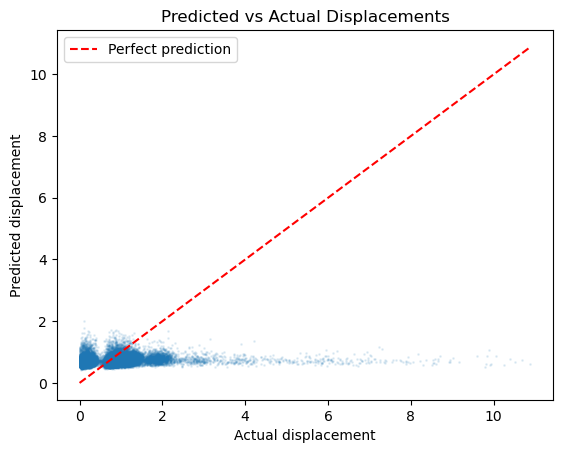

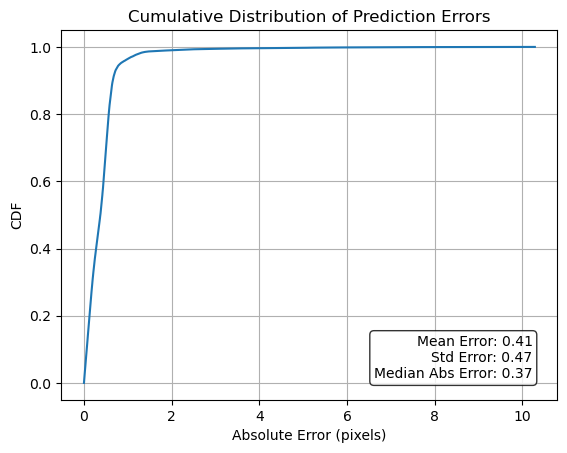


Neighbor weights:
[0.092, 0.092, -0.003, -0.003, -0.001, -0.001, 0.029, 0.029, 0.025, 0.025, -0.005, -0.005, -0.005, -0.005, 0.062, 0.062]
Intercept: 0.440


In [11]:
lin_reg = LinearRegression()
lin_reg_err = eval_model(lin_reg, return_err=True)

## ridge

Mean Squared Error: 0.391
Mean Absolute Error: 0.408
R² Score: 0.032


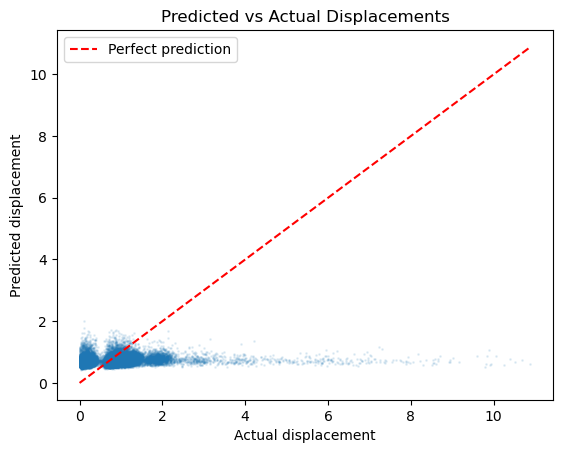

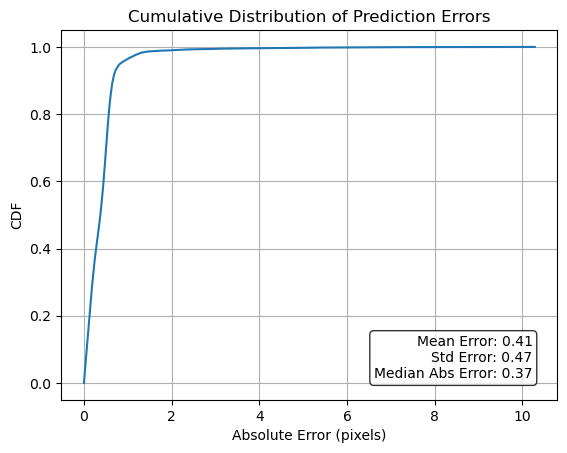


Neighbor weights:
[0.092, 0.092, -0.003, -0.003, -0.001, -0.001, 0.029, 0.029, 0.025, 0.025, -0.005, -0.005, -0.005, -0.005, 0.062, 0.062]
Intercept: 0.440


In [12]:
ridge_reg = Ridge(alpha=0.1)
ridge_reg_err = eval_model(ridge_reg, return_err=True)

## lasso

Mean Squared Error: 0.404
Mean Absolute Error: 0.416
R² Score: -0.000


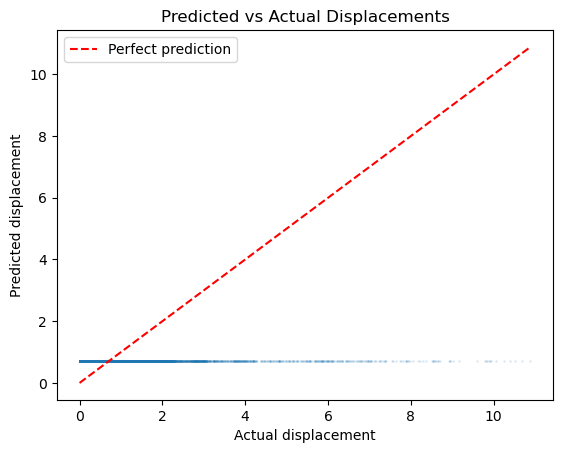

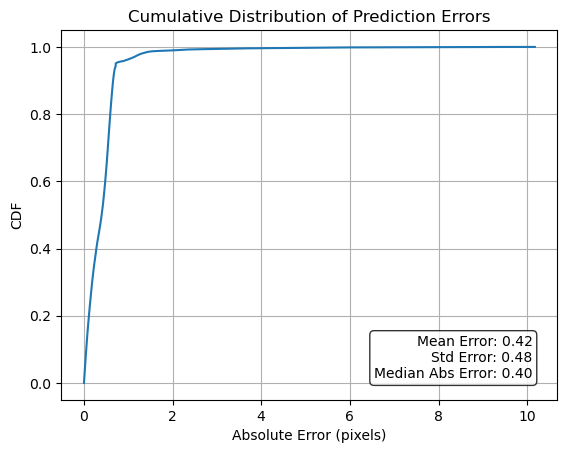


Neighbor weights:
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Intercept: 0.715


In [13]:
lasso_reg = Lasso(alpha=0.1)
lasso_reg_err = eval_model(lasso_reg, return_err=True)

## polynomial

Mean Squared Error: 0.382
Mean Absolute Error: 0.401
R² Score: 0.054


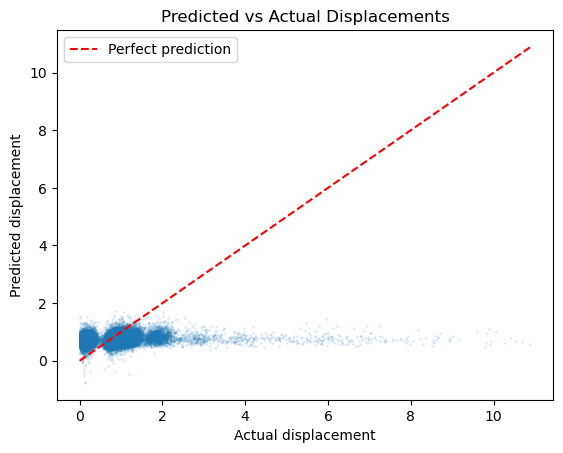

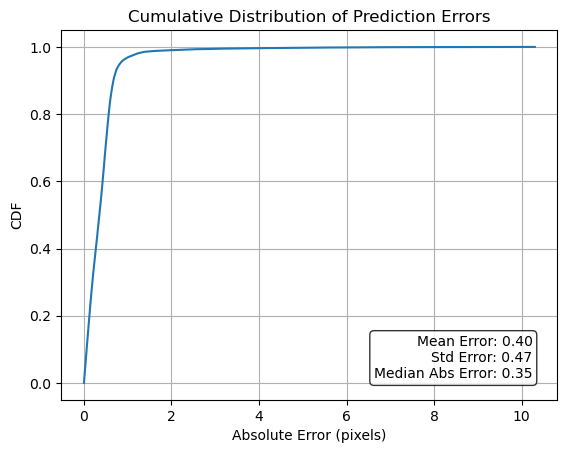


Neighbor weights:
[0.0, 0.093, 0.135, -0.043, -0.039, -0.019, -0.054, 0.012, -0.025, -0.007, 0.05, -0.047, -0.047, -0.049, -0.056, 0.123, 0.064, -0.018, 0.009, 0.015, -0.006, 0.015, 0.002, 0.003, 0.007, 0.001, 0.02, 0.012, 0.013, -0.0, 0.024, -0.007, -0.004, -0.027, 0.02, -0.003, 0.002, -0.002, 0.004, 0.006, 0.014, 0.006, -0.005, 0.019, -0.008, -0.01, 0.007, 0.04, 0.001, -0.01, -0.009, -0.004, -0.017, 0.004, 0.024, -0.019, 0.015, 0.003, -0.005, 0.007, 0.01, 0.0, 0.001, 0.011, 0.018, 0.027, -0.014, -0.005, -0.005, 0.009, 0.0, 0.003, -0.008, 0.003, 0.013, -0.003, 0.006, -0.004, 0.023, -0.003, 0.005, 0.006, -0.003, 0.004, 0.005, 0.002, -0.021, 0.004, 0.011, 0.006, -0.001, 0.011, -0.01, 0.006, 0.004, 0.013, -0.017, 0.003, -0.005, -0.015, 0.007, -0.006, -0.003, 0.02, 0.023, 0.009, -0.015, 0.007, 0.0, 0.006, 0.008, 0.011, 0.017, 0.021, 0.017, -0.01, -0.017, 0.003, -0.014, 0.027, -0.01, -0.01, -0.008, 0.001, -0.013, -0.006, -0.015, 0.008, -0.008, -0.007, 0.004, 0.004, 0.001, 0.0, -0.002, 0.0

In [18]:
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2)
X_poly = poly_features.fit_transform(X_data)
poly_reg = LinearRegression()
poly_reg_err = eval_model(poly_reg, X_data=X_poly, y_data=y_data, return_err=True)

# compare all errors

In [14]:
lin_reg_err.shape, max_err.shape

((50983,), (50983,))

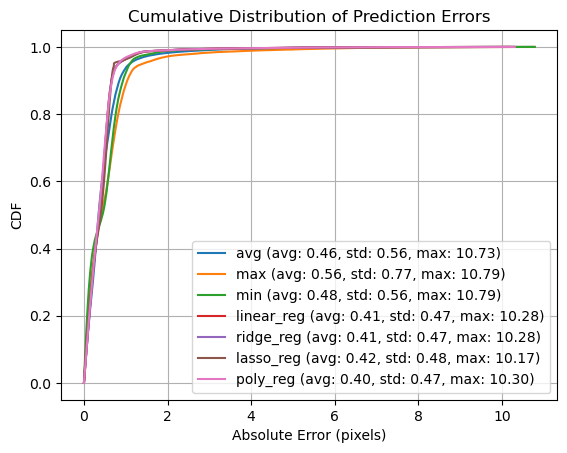

In [19]:
all_err = [avg_err, max_err, min_err, lin_reg_err, ridge_reg_err, lasso_reg_err, poly_reg_err]
all_err_names = ['avg', 'max', 'min', 'linear_reg', 'ridge_reg', 'lasso_reg', 'poly_reg']

def get_err_stats_str(err):
    mean_err = np.mean(err)
    std_err = np.std(err)
    max_err = np.max(err)
    return f' (avg: {mean_err:.2f}, std: {std_err:.2f}, max: {max_err:.2f})'

for err, name in zip(all_err, all_err_names):
    plt.plot(np.sort(np.abs(err)), np.arange(len(err))/len(err), label=name + get_err_stats_str(err))
plt.xlabel('Absolute Error (pixels)')
plt.ylabel('CDF')
plt.title('Cumulative Distribution of Prediction Errors')
plt.grid(True)
plt.legend()
plt.show()
